In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

## Reproducibility of NMF-Derived Taxonomic ESs

### Export NMF results and metadata 

In [33]:
k = 5
data_type = 'genera' 

results_path = f"../results/genera/random_split/nmf_trained/nsig_{k}"

In [34]:
W_path = f'{results_path}/best_run/W_{k}.csv'
H_train_path = f'{results_path}/best_run/H_train_{k}.csv'
H_test_path = f'{results_path}/best_run/H_test_{k}.csv'

W = pd.read_csv(W_path, index_col=0)
H_train = pd.read_csv(H_train_path, index_col=0)
H_test = pd.read_csv(H_test_path, index_col=0)

W.columns = [i for i in range(1, k + 1)]
H_train.index = [i for i in range(1, k + 1)]
H_test.index = [i for i in range(1, k + 1)]

genera_metadata = pd.read_csv("../data/genera_metadata.tsv", sep="\t", index_col=None) # tsv with columns 'genus','phylum'

In [35]:
# Names ES - Find dominant genus per ES
ES_names = []

for i in range(1, k + 1):
    column_data = W[i]
    dominant_genus = column_data.idxmax()
    # Special case
    if dominant_genus == 'Agathobacter' or dominant_genus == 'Faecalibacterium':
        dominant_genus = 'Firmicutes'
    ES_names.append(f"ES_{dominant_genus[:4]}")

W.columns = ES_names
H_train.index = ES_names
H_test.index = ES_names

In [36]:
# By normalizing the H matrix column-wise, we obtained the relative abundance of ES in each sample. We define as primary ES the ES of a sample with the highest relative abundance.
H_train_norm = H_train.div(H_train.sum(axis=0), axis=1) * 100
H_test_norm = H_test.div(H_test.sum(axis=0), axis=1) * 100

# Normalizing W by its its rows or columns informs on the general composition of ESs in genera, and on the association strength of genera to each ES, respectively
W_norm_row  = W.div(W.sum(axis=1), axis=0) * 100 # Informs on the general composition of ESs in genera
W_norm_col  = W.div(W.sum(axis=0), axis=1) * 100 # Find association strength of genera to each ES

In [ ]:
# Prepare dataframe
W_df_annot = W_norm_col.copy()
W_df_annot = W_df_annot.join(genera_metadata.set_index('genus'))
W_df_annot = W_df_annot.reset_index().sort_values(['phylum', 'index']).set_index('index')

### Plot distribution of genera per ES

Figure 5.1: (A) "Relative genus-level composition of each taxonomic ES"

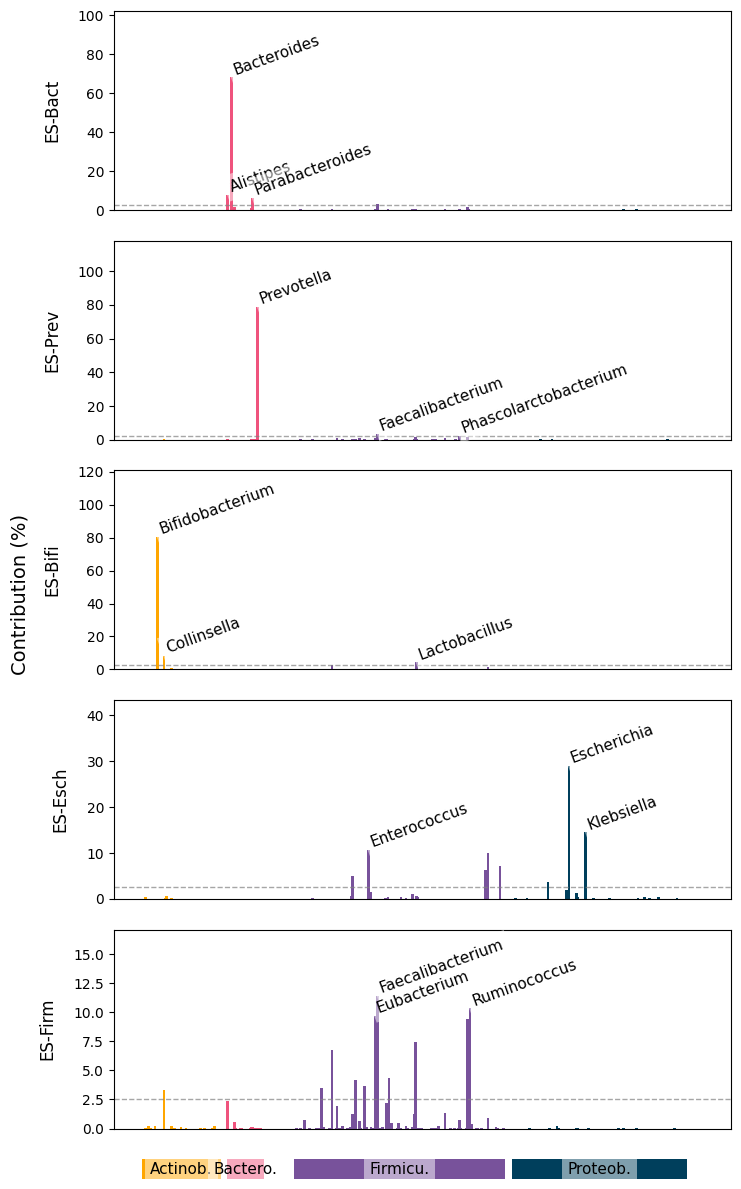

In [ ]:
n_groups = len(ES_names)
n_rows = n_groups + 1  # phyla annotation bar

height_ratios = [1] * n_groups + [0.1]
fig, axes = plt.subplots(n_rows, 1, figsize=(8, 12),
                         gridspec_kw={'height_ratios': height_ratios})

#############################################################################

# LABELS
component_labels = [
    'ES-Bact',
    'ES-Prev',
    'ES-Bifi',
    'ES-Esch',
    'ES-Firm']

highlight_phyla = [
    'Actinobacteria',
    'Bacteroidetes',
    'Firmicutes',
    'Proteobacteria',
    '']

colors = [
    '#ffa600',
    '#ef537d',
    '#78529b',
    '#003f5c',
    '']

phyla_colors = {phylum: colors[i] for i, phylum in enumerate(highlight_phyla)} # selected phyla
default_color = 'white' # other phyla

#############################################################################

# PLOT ESs composition
for i, group in enumerate(ES_names):

    contributions = W_df_annot[group]

    # Assign colors based on phylum
    phyla = W_df_annot['phylum']
    bar_colors = []

    for phylum in phyla:
        if phylum in phyla_colors:
            bar_colors.append(phyla_colors[phylum])
        else:
            bar_colors.append(default_color)

    axes[i].bar(range(len(contributions)),
                contributions.values,
                color=bar_colors,
                width=2)
    axes[i].set_xticks([])


    # 2.5 % line
    axes[i].axhline(y=2.5,
                    color='gray',
                    linestyle='--',
                    linewidth=1,
                    alpha=0.7)


    # Label ES on left
    axes[i].set_ylabel(component_labels[i],
                       fontsize=12,
                       rotation=90,
                       labelpad=12)

    # Annotate top 3 genera
    top_indices = contributions.nlargest(3).index
    top_values = contributions.nlargest(3).values

    for _, (genus, value) in enumerate(zip(top_indices, top_values)):
        position = list(W_df_annot.index).index(genus)

        if genus.endswith('_unclassified'):
            genus = genus.split('_')[0]

        axes[i].text(x=position, 
                     y=value,
                     s=genus,
                     rotation=20,
                     fontsize=11,
                     ha='left',
                     va='bottom',
                     bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))
    # y-axis limits
    axes[i].set_ylim(0, max(5, contributions.max() * 1.5))

# Common y-axis label
fig.supylabel('Contribution (%)', fontsize=14, x=0.08)

#############################################################################

# PLOT BOTTOM PHYLA BAR
bottom = axes[-1]
bottom.axis('off')

phylum_colors_bottom = []

for phylum in W_df_annot['phylum']:
    if phylum in phyla_colors:
        phylum_colors_bottom.append(phyla_colors[phylum])
    else:
        phylum_colors_bottom.append(default_color)


bottom.bar(x=range(len(W_df_annot)),
            height=[1] * len(W_df_annot),
            color=phylum_colors_bottom,
            width=1)

bottom.set_ylim(0, 1)
bottom.set_xticks([])
bottom.set_yticks([])

current_phylum = None
start_j = 0
phyla_series = W_df_annot['phylum'].values

for j, phylum in enumerate(phyla_series):
    if phylum != current_phylum:
        if current_phylum is not None and current_phylum in highlight_phyla:
            mid_pos = (start_j + j - 1) / 2

            bottom.text(x=mid_pos, 
                        y=0.5,
                        s=f'{current_phylum[:7]}.', # Num of letters
                        color='black',
                        ha='center',
                        va='center',
                        fontsize=11,
                        bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))
        current_phylum = phylum
        start_j = j

# label last segment
if current_phylum is not None:
    mid_pos = (start_j +len(phyla_series) - 1) / 2

    if (current_phylum in highlight_phyla or (len(phyla_series) - start_j) > 5):
        bottom.text(x=mid_pos, 
                    y=0.5,
                    s=f'{current_phylum[:7]}.', # Num of letters
                    color='black',
                    ha='center',
                    va='center',
                    fontsize=11,
                    bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

#############################################################################
plt.tight_layout(rect=[0.06, 0, 1, 1])
plt.savefig('../images/WW_ESgenera.png', dpi=300, bbox_inches='tight')
plt.show()
